# 03 — Huấn luyện và đánh giá mô hình ABSA Sentiment

Notebook này trình bày phần **modeling & evaluation** của đồ án

Mục tiêu:
- Mô tả bài toán Aspect-Based Sentiment Analysis
- Trình bày mô hình PhoBERT ABSA hai bước
- Xem lại kết quả train/evaluate
- Chạy inference demo
- Giải thích ý nghĩa output dự đoán

## 1. Khởi tạo môi trường

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

def find_project_root() -> Path:
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if (p / "src").exists() and (p / "data").exists():
            return p
    if cur.name.lower() == "notebooks":
        return cur.parent
    return cur

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from src.modeling.model import get_aspect_names, get_polarity_names

ASPECT_NAMES = get_aspect_names()
POLARITY_NAMES = get_polarity_names()

print("Số aspect:", len(ASPECT_NAMES))
print("Polarity:", POLARITY_NAMES)

PROJECT_ROOT: C:\Users\ADMIN\Downloads\Food_Review_NLP
Số aspect: 12
Polarity: ['none', 'positive', 'negative', 'neutral']


## 2. Bài toán mô hình hóa

Với mỗi review, model phải trả lời 2 câu hỏi:

1. Aspect này có được nhắc tới không?
2. Nếu có, cảm xúc là `positive`, `negative` hay `neutral`?

Vì vậy mô hình ABSA tốt hơn Sentiment Classification thông thường ở điểm:  
**Một review có thể có nhiều cảm xúc khác nhau theo từng aspect**

Ví dụ:

```text
Đồ ăn ngon nhưng phục vụ chậm.
```

Kết quả đúng nên là:
- `FOOD#QUALITY → positive`
- `SERVICE#GENERAL → negative`

## 3. Đọc dữ liệu processed và split train/dev/test

In [2]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

def load_processed() -> pd.DataFrame:
    files = sorted(PROCESSED_DIR.glob("*.parquet"))
    if not files:
        print("Chưa có file processed. Hãy chạy: python -m src.train --reprocess")
        return pd.DataFrame()
    vlsp_files = [p for p in files if "VLSP2018" in p.name]
    path = vlsp_files[0] if vlsp_files else files[0]
    print("Đọc file:", path)
    return pd.read_parquet(path)

df = load_processed()
print("Shape:", df.shape)
display(df.head(3))

if not df.empty and "type" in df.columns:
    display(df["type"].value_counts().rename_axis("split").reset_index(name="count"))

Đọc file: C:\Users\ADMIN\Downloads\Food_Review_NLP\data\processed\VLSP2018-ABSA-Restaurant.parquet
Shape: (4751, 17)


,Review,AMBIENCE#GENERAL,DRINKS#PRICES,DRINKS#QUALITY,DRINKS#STYLE&OPTIONS,FOOD#PRICES,FOOD#QUALITY,FOOD#STYLE&OPTIONS,LOCATION#GENERAL,RESTAURANT#GENERAL,RESTAURANT#MISCELLANEOUS,RESTAURANT#PRICES,SERVICE#GENERAL,type,dataset,phobert_text,aspect_sentiment
0,"_ Ảnh chụp từ hôm qua, đi chơi với gia đình và 1 nhà họ hàng đang sống tại Sài Gòn. _ Hôm qua đi ăn trưa muộn, ai cũng đói hết nên lúc có đồ ăn là nhào vô ă...",0,0,0,0,0,3,3,0,0,0,0,0,train,VLSP2018-ABSA-Restaurant,"_ Ảnh chụp từ hôm_qua , đi chơi với gia_đình và 1 nhà họ_hàng đang sống tại Sài_Gòn . _ Hôm_qua đi ăn trưa muộn , ai cũng đói hết nên lúc có đồ_ăn là nhào v...","{""FOOD#QUALITY"": 3, ""FOOD#STYLE&OPTIONS"": 3}"
1,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm nếm vừa miệng. Ngoài ra menu quán cũng nhiều món khác nhau tha hồ cho bạn lựa chọn luôn._Quán rộng rãi, view ...",1,0,0,0,3,1,1,0,1,0,3,2,train,VLSP2018-ABSA-Restaurant,"_Hương_vị thơm ngon , ăn cay_cay rất thích , nêm_nếm vừa miệng . Ngoài_ra thực_đơn_quán cũng nhiều món khác nhau tha_hồ cho bạn lựa_chọn luôn . _Quán rộng_r...","{""AMBIENCE#GENERAL"": 1, ""FOOD#PRICES"": 3, ""FOOD#QUALITY"": 1, ""FOOD#STYLE&OPTIONS"": 1, ""RESTAURANT#GENERAL"": 1, ""RESTAURANT#PRICES"": 3, ""SERVICE#GENERAL"": 2}"
2,"- 1 bàn tiệc hoành tráng 3 đứa ăn no muốn tắt thở mà giá chỉ 228k (ăn trung đợt giảm 10%), mình thích nhất pad thái vs gà nướng - đúng kiểu Thái luôn, quán ...",2,0,0,0,1,1,1,2,1,1,0,1,train,VLSP2018-ABSA-Restaurant,"- 1 bàn tiệc hoành_tráng 3 đứa ăn_no muốn tắt_thở mà giá chỉ 228 k ( ăn trung_đợt giảm 10 say_xỉn , mình thích nhất pad_thái với gà_nướng - đúng kiểu Thái l...","{""AMBIENCE#GENERAL"": 2, ""FOOD#PRICES"": 1, ""FOOD#QUALITY"": 1, ""FOOD#STYLE&OPTIONS"": 1, ""LOCATION#GENERAL"": 2, ""RESTAURANT#GENERAL"": 1, ""RESTAURANT#MISCELLANE..."


,split,count
0,train,2961
1,dev,1290
2,test,500


## 4. Kiểm tra phân bố nhãn theo aspect

Bảng này giải thích tại sao không nên chỉ dùng `accuracy`: dữ liệu có nhiều lớp và bị mất cân bằng

,aspect,none,positive,negative,neutral,mentioned,mention_rate
5,FOOD#QUALITY,476,3745,92,438,4275,0.899811
6,FOOD#STYLE&OPTIONS,2086,2272,154,239,2665,0.560935
4,FOOD#PRICES,2295,1203,210,1043,2456,0.516944
8,RESTAURANT#GENERAL,3442,1213,55,41,1309,0.275521
11,SERVICE#GENERAL,3553,920,164,114,1198,0.252157
0,AMBIENCE#GENERAL,3554,843,151,203,1197,0.251947
7,LOCATION#GENERAL,4065,221,95,370,686,0.144391
9,RESTAURANT#MISCELLANEOUS,4353,183,62,153,398,0.083772
10,RESTAURANT#PRICES,4380,226,30,115,371,0.078089
2,DRINKS#QUALITY,4527,176,21,27,224,0.047148


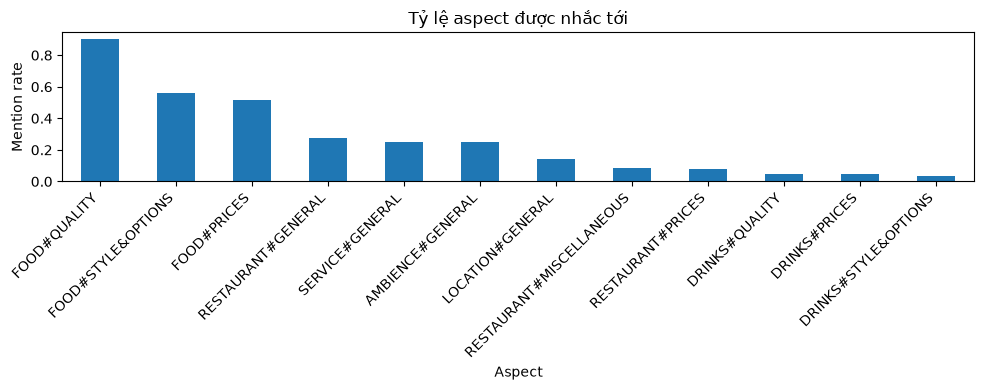

In [3]:
if not df.empty:
    rows = []
    for aspect in ASPECT_NAMES:
        if aspect not in df.columns:
            continue
        vc = df[aspect].fillna(0).astype(int).value_counts().to_dict()
        rows.append({
            "aspect": aspect,
            "none": vc.get(0, 0),
            "positive": vc.get(1, 0),
            "negative": vc.get(2, 0),
            "neutral": vc.get(3, 0),
            "mentioned": len(df) - vc.get(0, 0),
            "mention_rate": (len(df) - vc.get(0, 0)) / len(df),
        })
    label_dist = pd.DataFrame(rows).sort_values("mention_rate", ascending=False)
    display(label_dist)

    ax = label_dist.plot(x="aspect", y="mention_rate", kind="bar", legend=False, figsize=(10, 4))
    ax.set_title("Tỷ lệ aspect được nhắc tới")
    ax.set_xlabel("Aspect")
    ax.set_ylabel("Mention rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Lệnh train mô hình

Để tránh notebook chạy quá lâu khi trình bày, ta train bằng terminal.  
Lệnh:

```powershell
python -m src.train --reprocess --clean_checkpoints --eval_test --epochs 10 --batch_size 16 --max_len 192 --lr 2e-5
```

Nếu GPU yếu hoặc thiếu VRAM:

```powershell
python -m src.train --reprocess --clean_checkpoints --eval_test --epochs 10 --batch_size 8 --max_len 192 --lr 2e-5
```

In [4]:
# Chỉ bật True nếu muốn train ngay trong notebook
# Thường nên train bằng terminal để dễ theo dõi log
TRAIN_NOW = False

if TRAIN_NOW:
    import subprocess
    cmd = [
        sys.executable, "-m", "src.train",
        "--reprocess",
        "--clean_checkpoints",
        "--eval_test",
        "--epochs", "10",
        "--batch_size", "16",
        "--max_len", "192",
        "--lr", "2e-5",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=str(PROJECT_ROOT), check=True)
else:
    print("TRAIN_NOW = False. Notebook chỉ trình bày và đọc kết quả đã train.")

TRAIN_NOW = False. Notebook chỉ trình bày và đọc kết quả đã train.


## 6. Đọc kết quả đánh giá đã lưu

Sau khi train, chương trình lưu report vào `outputs/metrics/`

Các chỉ số quan trọng:
- **Aspect Precision/Recall/F1**: phát hiện đúng aspect hay không
- **Aspect + Polarity F1**: đúng cả aspect và sentiment
- **Exact row match**: toàn bộ 12 aspect của một review đều đúng

In [5]:
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

def load_json(path: Path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_overall(report: dict, split_name: str) -> dict:
    overall = report.get("_overall", {}) if isinstance(report, dict) else {}
    return {
        "split": split_name,
        "aspect_precision": overall.get("aspect_precision"),
        "aspect_recall": overall.get("aspect_recall"),
        "aspect_f1": overall.get("aspect_f1"),
        "polarity_precision": overall.get("polarity_precision"),
        "polarity_recall": overall.get("polarity_recall"),
        "polarity_f1": overall.get("polarity_f1"),
        "label_accuracy": overall.get("label_accuracy"),
        "exact_row_match": overall.get("exact_row_match"),
    }

reports = []
loaded_reports = {}

for split in ["val", "test"]:
    path = METRICS_DIR / f"{split}_classification_report.json"
    report = load_json(path)
    if report is not None:
        loaded_reports[split] = report
        reports.append(extract_overall(report, split))

if reports:
    summary_df = pd.DataFrame(reports)
    display(summary_df)
else:
    print("Chưa tìm thấy classification report.")
    print("Hãy chạy train trước, ví dụ: python -m src.train --reprocess --eval_test")

,split,aspect_precision,aspect_recall,aspect_f1,polarity_precision,polarity_recall,polarity_f1,label_accuracy,exact_row_match
0,val,0.652574,0.802498,0.719812,0.574634,0.706651,0.633841,0.839729,0.22093


## 7. Bảng F1 theo từng aspect

Bảng này cho thấy model mạnh/yếu ở aspect nào

,aspect,accuracy,macro_f1,weighted_f1,support
4,FOOD#PRICES,0.831783,0.796583,0.833840,1290.0
5,FOOD#QUALITY,0.825581,0.622765,0.813424,1290.0
0,AMBIENCE#GENERAL,0.879845,0.583680,0.883949,1290.0
3,DRINKS#STYLE&OPTIONS,0.987597,0.571989,0.988410,1290.0
11,SERVICE#GENERAL,0.884496,0.548486,0.878848,1290.0
1,DRINKS#PRICES,0.952713,0.440994,0.949182,1290.0
7,LOCATION#GENERAL,0.858140,0.439610,0.873395,1290.0
6,FOOD#STYLE&OPTIONS,0.592248,0.385800,0.594123,1290.0
9,RESTAURANT#MISCELLANEOUS,0.774419,0.374241,0.821554,1290.0
8,RESTAURANT#GENERAL,0.691473,0.319814,0.716344,1290.0


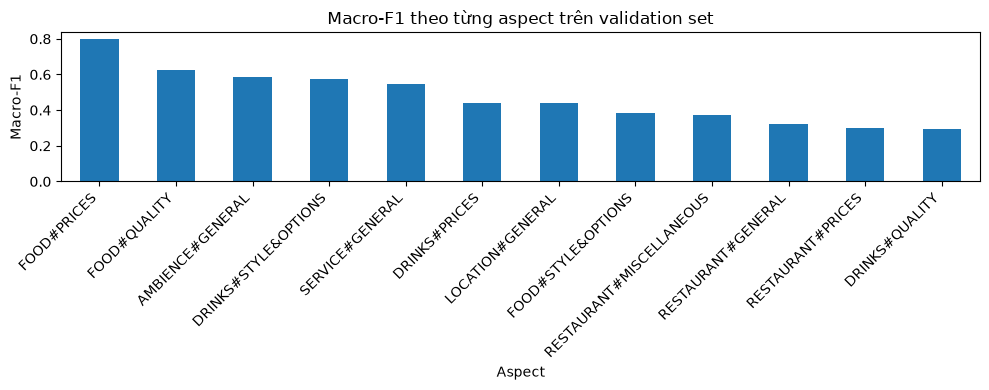

In [6]:
def aspect_f1_table(report: dict) -> pd.DataFrame:
    rows = []
    if not isinstance(report, dict):
        return pd.DataFrame()
    for aspect, data in report.items():
        if aspect.startswith("_") or not isinstance(data, dict):
            continue
        rows.append({
            "aspect": aspect,
            "accuracy": data.get("accuracy"),
            "macro_f1": data.get("macro avg", {}).get("f1-score"),
            "weighted_f1": data.get("weighted avg", {}).get("f1-score"),
            "support": data.get("macro avg", {}).get("support"),
        })
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False)

if "val" in loaded_reports:
    val_aspect_table = aspect_f1_table(loaded_reports["val"])
    display(val_aspect_table)

    if not val_aspect_table.empty:
        ax = val_aspect_table.plot(x="aspect", y="macro_f1", kind="bar", legend=False, figsize=(10, 4))
        ax.set_title("Macro-F1 theo từng aspect trên validation set")
        ax.set_xlabel("Aspect")
        ax.set_ylabel("Macro-F1")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("Chưa có val report để hiển thị.")

## 8. Hiển thị confusion matrix nếu có

Confusion matrix giúp phân tích model thường nhầm:
- `none → positive/negative/neutral`: đoán thừa aspect
- `positive/negative/neutral → none`: bỏ sót aspect
- `positive ↔ negative/neutral`: sai polarity

Confusion matrix: val


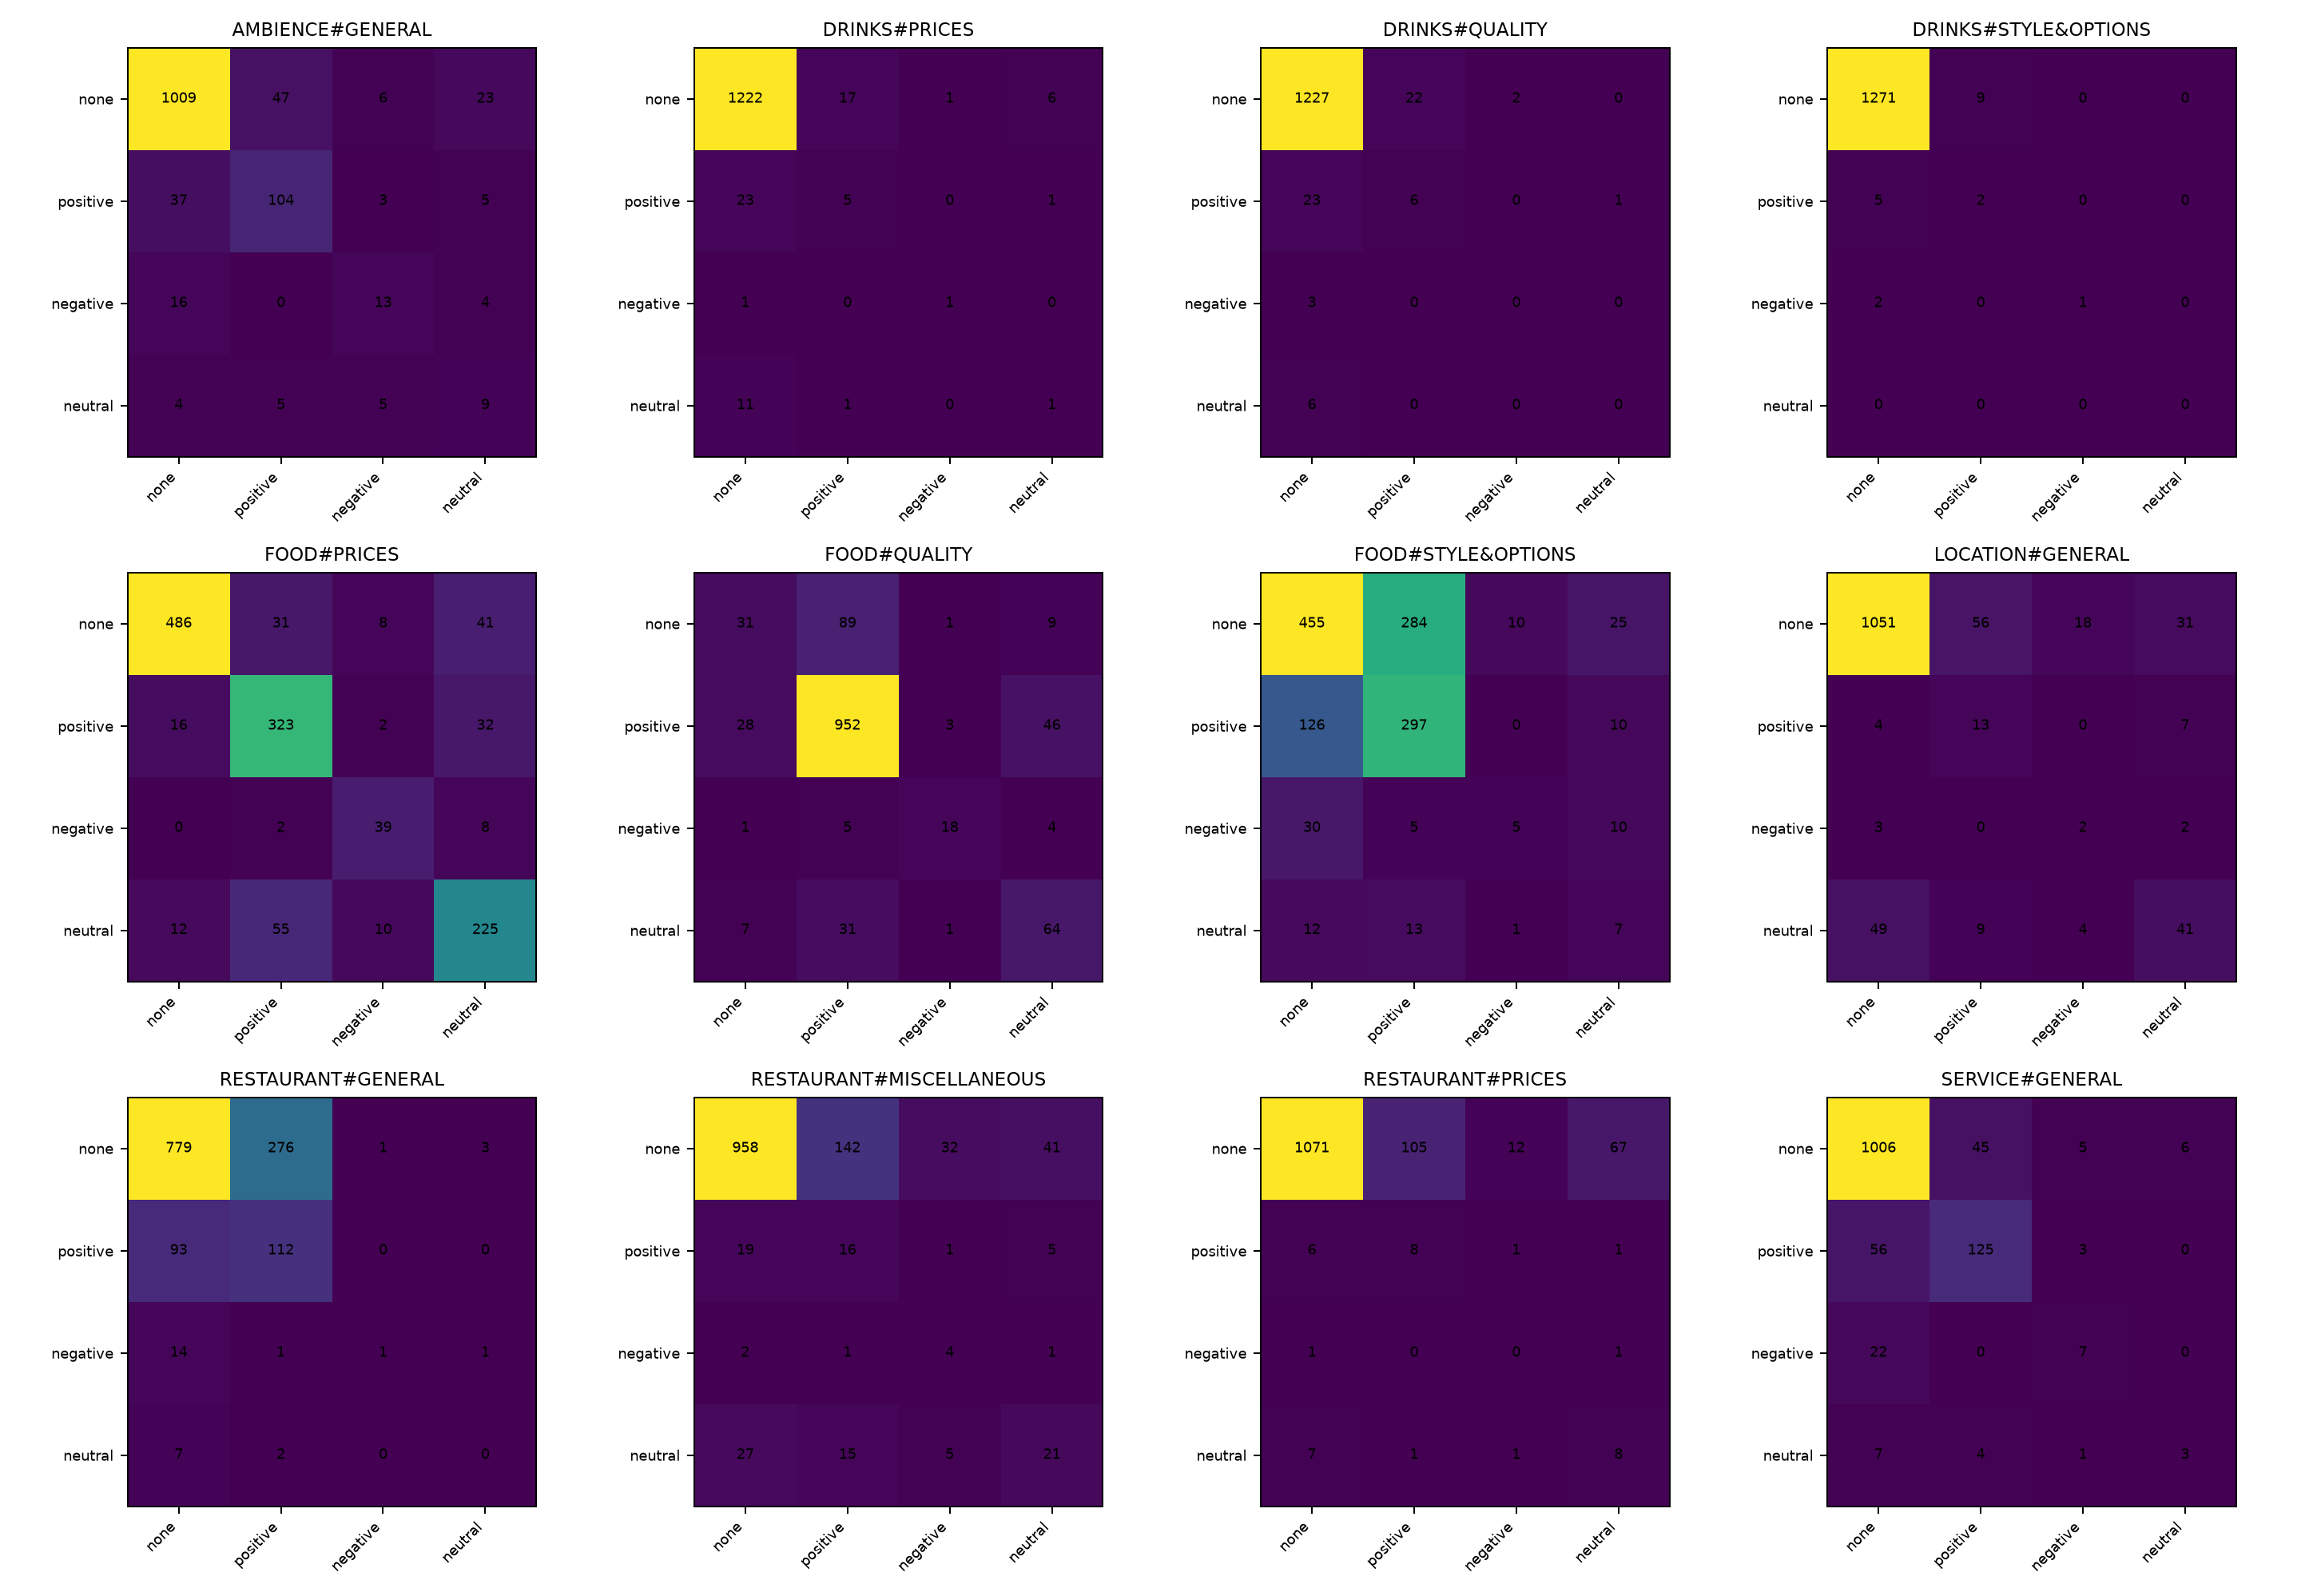

Chưa có test_confusion_matrix.png


In [7]:
for split in ["val", "test"]:
    fig_path = FIGURES_DIR / f"{split}_confusion_matrix.png"
    if fig_path.exists():
        print(f"Confusion matrix: {split}")
        display(Image(filename=str(fig_path)))
    else:
        print(f"Chưa có {fig_path.name}")

## 9. Chạy inference thử

Cell này dùng model đã train trong `models/saved_models/best_model`

Nếu chưa train, cell sẽ thông báo cách train trước

In [8]:
CHECKPOINT_DIR = (
    PROJECT_ROOT / "models" / "saved_models" / "best_model"
).resolve()

examples = [
    "Đồ ăn ngon mê mẩn, phục vụ chậm, nhưng không gian đẹp.",
    "Giá hợp lý nhưng món ăn hơi mặn.",
    "Quán khó tìm, nhân viên nhiệt tình, trà sữa hơi ngọt.",
]

# Kiểm tra model bằng các file bắt buộc thay vì chỉ kiểm tra thư mục.
required_model_files = [
    CHECKPOINT_DIR / "config.json",
    CHECKPOINT_DIR / "model.safetensors",
    CHECKPOINT_DIR / "tokenizer_config.json",
]

missing_model_files = [
    path.name for path in required_model_files if not path.exists()
]

print("Checkpoint đang dùng:", CHECKPOINT_DIR)

if CHECKPOINT_DIR.exists() and not missing_model_files:
    from src.modeling.inference import predict

    for text in examples:
        print("=" * 100)
        print("REVIEW:", text)

        # Quan trọng:
        # Truyền đường dẫn tuyệt đối vào predict().
        # Nếu không truyền, inference.py có thể tìm đường dẫn tương đối
        # models/saved_models/best_model theo thư mục làm việc hiện tại
        # của Jupyter thay vì theo PROJECT_ROOT.
        result = predict(
            text,
            checkpoint_path=str(CHECKPOINT_DIR),
        )

        print(
            "PREPROCESSED:",
            result.get("preprocessed_text", ""),
        )

        mentioned = result.get("mentioned_aspects", [])
        if mentioned:
            display(pd.DataFrame(mentioned))
        else:
            print("Không phát hiện aspect nào.")

        sarcasm = result.get("sarcasm_warning")
        if sarcasm:
            print("Sarcasm warning:", sarcasm)
else:
    print("Không thể load model tại:", CHECKPOINT_DIR)

    if missing_model_files:
        print(
            "Các file model còn thiếu:",
            ", ".join(missing_model_files),
        )

    print(
        "Hãy train trước bằng:",
        "python -m src.train --reprocess --clean_checkpoints --eval_test",
    )


Checkpoint đang dùng: C:\Users\ADMIN\Downloads\Food_Review_NLP\models\saved_models\best_model
REVIEW: Đồ ăn ngon mê mẩn, phục vụ chậm, nhưng không gian đẹp.
✓ Đã tải model: C:\Users\ADMIN\Downloads\Food_Review_NLP\models\saved_models\best_model
  Device     : cuda
  Thresholds : [0.7, 0.48, 0.46, 0.48, 0.62, 0.8, 0.68, 0.6, 0.58, 0.32, 0.56, 0.7]
PREPROCESSED: Đồ_ăn ngon_mê mẩn , phục_vụ chậm , nhưng không_gian đẹp .


,aspect,polarity,confidence,polarity_confidence,effective_threshold,evidence_status,aspect_source,polarity_source,keyword_hits
0,FOOD#QUALITY,positive,0.893643,0.993265,0.800000,explicit_evidence_supported,model_threshold,explicit_evidence_override,"[ngon, đồ_ăn]"
1,SERVICE#GENERAL,negative,0.609768,0.647694,0.609768,explicit_evidence_rescue,explicit_evidence_rescue,explicit_evidence_override,"[chậm, phục_vụ]"
2,AMBIENCE#GENERAL,positive,0.592691,0.653782,0.592691,explicit_evidence_rescue,explicit_evidence_rescue,explicit_evidence_override,"[không_gian, đẹp]"


Sarcasm warning: {'sarcasm_detected': True, 'signals': ['positive_negative_contrast'], 'note': 'Chỉ là heuristic cảnh báo. Muốn phát hiện sarcasm chắc hơn cần dataset có nhãn sarcasm.'}
REVIEW: Giá hợp lý nhưng món ăn hơi mặn.
PREPROCESSED: Giá hợp_lý nhưng món_ăn hơi mặn .


,aspect,polarity,confidence,polarity_confidence,effective_threshold,evidence_status,aspect_source,polarity_source,keyword_hits
0,FOOD#PRICES,positive,0.828956,0.991682,0.62,explicit_evidence_supported,model_threshold,explicit_evidence_override,"[giá, giá hợp_lý, hợp_lý]"
1,FOOD#QUALITY,negative,0.802813,0.838337,0.80,explicit_evidence_supported,model_threshold,explicit_evidence_override,"[món, món_ăn, mặn]"


Sarcasm warning: {'sarcasm_detected': False, 'signals': [], 'note': 'Chỉ là heuristic cảnh báo. Muốn phát hiện sarcasm chắc hơn cần dataset có nhãn sarcasm.'}
REVIEW: Quán khó tìm, nhân viên nhiệt tình, trà sữa hơi ngọt.
PREPROCESSED: Quán khó tìm , nhân_viên nhiệt_tình , trà_sữa hơi ngọt .


,aspect,polarity,confidence,polarity_confidence,effective_threshold,evidence_status,aspect_source,polarity_source,keyword_hits
0,SERVICE#GENERAL,positive,0.722275,0.587246,0.7,explicit_evidence_supported,model_threshold,explicit_evidence_override,"[nhiệt_tình, nhân_viên]"


Sarcasm warning: {'sarcasm_detected': False, 'signals': [], 'note': 'Chỉ là heuristic cảnh báo. Muốn phát hiện sarcasm chắc hơn cần dataset có nhãn sarcasm.'}


## 10. Ý nghĩa các trường trong output inference

Ví dụ output:

```json
{
  "aspect": "FOOD#QUALITY",
  "polarity": "positive",
  "confidence": 0.9618,
  "polarity_confidence": 0.9951,
  "effective_threshold": 0.72,
  "evidence_status": "supported",
  "aspect_source": "model_threshold",
  "polarity_source": "model",
  "keyword_hits": ["mặn", "ngon", "nóng"]
}
```

| Trường | Ý nghĩa |
|---|---|
| `aspect` | Khía cạnh được phát hiện, ví dụ `FOOD#QUALITY`, `SERVICE#GENERAL`. |
| `polarity` | Cảm xúc cuối cùng của aspect: `positive`, `negative`, hoặc `neutral`. |
| `confidence` | Xác suất model cho rằng aspect này được nhắc tới. |
| `polarity_confidence` | Độ tin cậy của nhãn cảm xúc đã chọn. |
| `effective_threshold` | Ngưỡng thực tế dùng để quyết định giữ aspect hay loại bỏ. |
| `evidence_status` | Trạng thái bằng chứng ngữ cảnh, ví dụ `supported` là có bằng chứng rõ. |
| `aspect_source` | Nguồn quyết định aspect, ví dụ từ threshold model hoặc rescue bằng evidence rõ. |
| `polarity_source` | Nguồn quyết định polarity, ví dụ model hoặc heuristic override. |
| `keyword_hits` | Các từ/cụm từ trong review khớp với evidence dictionary. |

Cách đọc: aspect chỉ nên được tin tưởng cao khi `confidence >= effective_threshold` và `evidence_status = supported`

## 11. Kết luận

Mô hình trong đồ án không chỉ dự đoán sentiment chung của cả câu, mà phân tích cảm xúc theo từng khía cạnh. 
Điều này phù hợp hơn với review nhà hàng, vì một review có thể vừa khen món ăn, vừa chê phục vụ

Các điểm nổi bật:
- Dùng PhoBERT cho tiếng Việt
- Thiết kế theo hướng ABSA hai bước: aspect detection + polarity classification
- Xử lý mất cân bằng nhãn bằng threshold và loss weight
- Đánh giá bằng Aspect F1 và Aspect+Polarity F1
- Có inference trực quan, giải thích được lý do dự đoán thông qua evidence